# <center>行业联合动量因子</center>

# 动量策略的起源
## 三大互补选股维度
1、`Momentum:`**当价格延续前期运行趋势时**（即上涨标的持续走高、下跌标的持续走低），可获取相应收益；

2、`Value:`**当价格向前期某一均衡水平回归时**（即价格围绕基本面价值呈现均值回复特征），可获取相应收益；

3、`Carry:`**当价格保持平稳不变时**，可获取相应收益，主要体现为股东分红收益。

注：若买入某只股票并长期持有，在股价保持不变的前提下，投资者获得的收益即为该股票的分红收益，股息率（dividend yield）即为Carry收益率。

## 动量策略的发展
+ `1967年`，Robert Levy在*Journal of Finance*发表《Relative Strength as a Criterion for Investment Selection》一文，彼时“动量”这一专业术语尚未正式提出；

+ `1970年代开始`，有效市场假说（EMH）被提出并占据主流研究地位，**动量相关现象的研究受到显著压制**。随着市场认知不断深化以及价值投资取得显著成效，有效市场假说的权威性有所弱化，但动量策略仍被视作“一种黑色艺术、一类巫术魔力”；

+ `1993年`，Jegadeesh与Titman在*Journal of Finance*发表具有里程碑意义的论文《Return to Buying Winners and Selling Losers:Implications for Stock Market Efficiency》；

+ `2008年`，有效市场假说提出者Eugene Fama在接受美国金融协会采访时，正式承认动量效应的存在；

+ `2013年`，Asness等人在*Journal of Finance*发表具有广泛影响力的研究成果《Value and Momentum Everywhere》。

## Momentum和Value无处不在
**核心参考文献**
+ Asness, C. S., T. J. Moskowitz, and L. H. Pedersen (2013). Value and Momentum Everywhere. *Journal of Finance*, Vol.68(3), 929–985.
+ Gray, W. R. and J. R. Vogel (2016). Quantitative Momentum, a Practitioner’s Guide to Building a Momentum-Based Stock Selection System. John Wiley & Sons, Inc., Hoboken, New Jersey.

# 基础版动量策略
## 策略出发点
1、A股市场呈现**反转效应强于动量效应**的特征，海外主流的动量选股思路（采用t-12月至t-1月区间收益率进行选股）在国内市场适用性较差。
2、构建动量因子过程中，需要**重点关注因子在市值维度上的暴露程度**。

## 构造动量因子
采用过去60个交易日经风险调整后的涨跌幅作为动量因子，该因子与市值因子的相关系数仅为0.085，具体计算公式如下：

### $$r_{60}-3000*\sigma ^{2}$$

式中$r_{60}$为标的60日涨跌幅，即60个交易日区间收益率；$\sigma$为60个交易日收益率的标准差，用以衡量风险水平。

## 策略思想
1、回测时间区间：2010年1月1日至2020年12月31日；
2、调仓频率：按月调仓，每月末以收盘价完成股票交易；
3、选股范围：中证500成分股；剔除ST类个股；剔除因停牌等情形导致无法正常交易的标的；
4、交易规则：
+ 每月末更新动量因子数值并重新排序，单只标的目标仓位设定为1%，采用等权重方式配置；
+ 将中证500成分股依据因子值由小至大划分为5组，因子取值与组合收益呈正向相关，组别序号越高组合表现越优，即G5组表现优于G1组。

**备注：**日频调仓对日内数据需求量较大，因此本文采用月度调仓方式，用以体现高质量动量选股逻辑并展示相应选股效果。

In [1]:
# ==============================
# 基础数值计算与数据处理库
# ==============================
import numpy as np
import pandas as pd

# ==============================
# 金融绩效分析与因子分析工具库
# ==============================
import empyrical as ep
import alphalens as al
import alphalens.performance as performance
from alphalens import visualization

# ==============================
# 聚宽数据与因子计算专用库
# ==============================
from jqdata import *
from jqfactor import Factor, calculate_factors

# ==============================
# 类型标注、工具函数、进度条
# ==============================
from typing import Tuple, List
from functools import reduce
from tqdm import tqdm_notebook
from dateutil.parser import parse_date

# ==============================
# 可视化绘图相关库
# ==============================
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as date_formatter

# ==============================
# Matplotlib 全局绘图配置
# 解决中文字体、负号显示问题
# ==============================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.unicode_minus'] = False

# 统一设置图表风格为 seaborn
plt.style.use('seaborn')

In [21]:
# 交易日偏移计算工具
def shift_trade_day(base_date: str, step: int) -> datetime.date:
    '''
    基于交易日历进行日期偏移计算
    base_date: 计算基准日期
    step: 正数向后推移交易日，负数向前推移交易日
    -----------
    返回值：计算后的交易日日期对象
    '''

    target_trade_day = get_trade_days(end_date=base_date, count=1)[0]

    if step > 0:
        full_calendar = get_all_trade_days().tolist()
        day_position = full_calendar.index(target_trade_day)
        return full_calendar[day_position + step]

    elif step < 0:
        required_count = abs(step)
        return get_trade_days(end_date=target_trade_day, count=required_count)[0]

    else:
        raise ValueError("偏移步数不能为零，请输入有效数值！")


# 策略绩效评估函数
def evaluate_strategy_metrics(profit_series: pd.DataFrame, cycle='monthly') -> pd.DataFrame:
    '''
    计算策略核心风险收益指标，默认按月度频率统计
    '''

    metrics_table: pd.DataFrame = pd.DataFrame()
    metrics_table['年化收益'] = ep.annual_return(profit_series, period=cycle)
    metrics_table['年化波动'] = profit_series.apply(lambda x: ep.annual_volatility(x, period=cycle))
    metrics_table['夏普比率'] = profit_series.apply(ep.sharpe_ratio, period=cycle)
    metrics_table['最大回撤'] = profit_series.apply(lambda x: ep.max_drawdown(x))
    
    if 'benchmark' in profit_series.columns:
        strategy_cols = [col for col in profit_series.columns if col != 'benchmark']
        metrics_table['信息比率'] = profit_series[strategy_cols].apply(
            lambda x: calc_information_ratio(x, profit_series['benchmark']))
        metrics_table['超额Alpha'] = profit_series[strategy_cols].apply(
            lambda x: ep.alpha(x, profit_series['benchmark'], period=cycle))

    return metrics_table.T


# 信息比率计算
def calc_information_ratio(strategy_profit, benchmark_profit):
    """
    计算策略相对基准的信息比率指标
    """
    if len(strategy_profit) < 2:
        return np.nan

    excess_profit = adjust_profit_series(strategy_profit, benchmark_profit)
    tracking_error = np.std(excess_profit, ddof=1)
    
    if np.isnan(tracking_error):
        return 0.0
    if tracking_error == 0:
        return np.nan
        
    return np.mean(excess_profit) / tracking_error


# 收益序列调整
def adjust_profit_series(raw_profit, adjust_value):
    """
    对收益序列进行基准调整，返回新序列
    """
    if isinstance(adjust_value, (float, int)) and adjust_value == 0:
        return raw_profit.copy()
    return raw_profit - adjust_value


# 因子分组工具
def assign_factor_groups(raw_data: pd.DataFrame, target_factor: str, group_count: int=5) -> pd.DataFrame:
    '''
    按日期对因子值进行分位数分组
    ----
        target_factor: 需要分组的因子列
        group_count: 默认分为5组
    '''
    processed_data = raw_data.copy()
    group_labels = ['G%s' % idx for idx in range(1, group_count + 1)]
    
    processed_data['group'] = processed_data.groupby(level='date')[target_factor].transform(
        lambda series: pd.qcut(series, 5, labels=group_labels))
    
    return processed_data


# 计算分组收益
def compute_group_profit(factor_data: pd.DataFrame) -> pd.DataFrame:
    '''
    计算各分组的日度收益率序列
    ---------
    输入数据格式：
           ----------------------------------------------
                      |       |factor|group| next_return|
           ----------------------------------------------
               date   | asset |      |     |            |
           ----------------------------------------------
                      | AAPL  |  0.5 |  G1 |   0.23     |
                      -----------------------------------
                      | BA    | -1.1 |  G2 |   -0.7     |
                      -----------------------------------
           2014-01-01 | CMG   |  1.7 |  G2 |   0.023    |
                      -----------------------------------
                      | DAL   | -0.1 |  G3 |   -0.03    |
                      -----------------------------------
                      | LULU  |  2.7 |  G1 |   -0.21    |
                      -----------------------------------
    '''
    
    profit_pivot = pd.pivot_table(
        factor_data.reset_index(),
        index='date',
        columns='group',
        values='next_ret'
    )
    profit_pivot.columns = [str(name) for name in profit_pivot.columns]
    profit_pivot.index = pd.to_datetime(profit_pivot.index)
    
    return profit_pivot


# 净值曲线绘图
def draw_net_value_curve(net_value: pd.DataFrame, chart_title: str):
    '''
    绘制分组净值曲线
    ---------
    输入数据格式：
        -------------------------------------
        |  date    | 1  | 2  | 3  | 4  | 5  |
        -------------------------------------
        |2020-01-01|0.01|0.02|0.14|-0.2|0.08|
        -------------------------------------
        |2020-01-02|0.11|-0.2|-0.1|0.33|0.10|
        -------------------------------------
    '''

    plt.rcParams['font.family'] = 'serif'
    fig, axis = plt.subplots(figsize=(18, 6))
    
    plt.title(chart_title)
    
    # 绘制各组净值曲线，首尾两组突出显示
    axis.plot(net_value['G1'], color='Navy')
    axis.plot(net_value['G2'], color='LightGrey', linestyle='-.')
    axis.plot(net_value['G3'], color='DimGray', linestyle='-.')
    axis.plot(net_value['G4'], color='DarkKhaki', linestyle='-.')
    axis.plot(net_value['G5'], color='LightSteelBlue')
        
    axis.axhline(1, color='black', linewidth=0.5)
    
    # 绘制超额收益曲线
    axis.plot(net_value['excess_ret'], color='red', linestyle='--')
    
    # 若存在基准则绘制基准曲线
    if 'benchmark' in net_value.columns:
        axis.plot(net_value['benchmark'], color='black', linestyle='--')
    
    # 统一图例
    handles, labels = axis.get_legend_handles_labels()
    axis.legend(handles, labels)

### 提取调仓日期
首先提取2010年1月1日至2020年12月31日回测周期内的各月末交易日日期，再提取对应每月月末向前追溯60个交易日的日期，用于后续计算回测区间内各月末交易日对应的前60日涨跌幅数据。

In [3]:
# 获取指定频率的交易日时点（月末/季末/年末等）
def fetch_trade_period_points(start_date: str, end_date: str, freq: str = 'ME') -> list:
    '''
    获取指定周期内的期末/期初交易日节点
    start_date/end_date: 字符串格式 年-月-日
    freq: 周期规则，M=月，Q=季，Y=年；E=期末，S=期初，默认ME=月末
    ================
    返回值：交易日日期对象列表
    '''
    # 获取区间内所有交易日并转换为时间索引
    trade_days = pd.Index(pd.to_datetime(get_trade_days(start_date, end_date)))
    index_frame = trade_days.to_frame()

    # 根据期末/期初选择重采样方式
    if freq[-1] == 'E':
        period_days = index_frame.resample(freq[0]).last()
    else:
        period_days = index_frame.resample(freq[0]).first()

    # 转换为日期格式并清理空值
    period_days = period_days[0].dt.date

    return period_days.dropna().values.tolist()

### 构建选股函数
首先提取各调仓日期对应的中证500成分股标的，随后剔除ST股票以及因停牌等原因无法正常交易的个股，最终筛选并保留中证500内STT且可正常交易的股票。

In [4]:
# 获取筛选后的标的股票池
def fetch_target_stock_pool(index_symbol: str, analysis_date: str) -> list:
    '''
    根据指数代码获取股票池，并自动过滤ST、新股、停牌股票
    '''

    # 全市场股票池：上证指数 + 深证综指
    if index_symbol == 'A':
        stock_list = get_index_stocks('000002.XSHG', date=analysis_date) + get_index_stocks(
            '399107.XSHE', date=analysis_date)
    else:
        stock_list = get_index_stocks(index_symbol, date=analysis_date)
    
    # 执行多层过滤
    stock_list = exclude_st_stocks(stock_list, analysis_date)
    stock_list = exclude_new_listed(stock_list, analysis_date)
    stock_list = exclude_suspended_stocks(stock_list, analysis_date)

    return stock_list


# 过滤ST、*ST风险警示股票
def exclude_st_stocks(security_list: list, analysis_date: str) -> list:
    '''剔除风险警示标的，保留正常交易标的'''

    st_status = get_extras('is_st', security_list,
                          end_date=analysis_date, df=True, count=1).iloc[0]

    return st_status[st_status == False].dropna().index.tolist()


# 过滤上市时间不足的新股
def exclude_new_listed(security_list: list, analysis_date: str, min_listed_days: int = 60) -> list:
    '''保留上市天数超过指定阈值的股票'''
    return list(filter(lambda code: (parse(analysis_date).date() - get_security_info(code, date=analysis_date).start_date).days > min_listed_days, security_list))


# 过滤长期停牌股票
def exclude_suspended_stocks(security_list: list, analysis_date: str, check_period: int = 21) -> list:
    '''保留指定周期内从未停牌的正常交易股票'''
    suspend_data = get_price(security_list, end_date=analysis_date,
                         count=check_period, fields='paused', panel=False)
    suspend_summary = suspend_data.groupby('code')['paused'].sum()

    return suspend_summary[suspend_summary == 0].dropna().index.tolist()

### 构建动量因子
首先提取各调仓日符合选股条件标的所对应的**前60日涨跌幅**数据，随后获取各只股票**前60日收益波动率**指标，最终通过既定的因子计算公式完成**动量因子数值的计算**。

In [5]:
class TrendMomentumIndicator(Factor):
    """
    趋势动量因子指标
    基于价格收益率与波动率调整计算动量得分
    """
    
    import warnings
    warnings.filterwarnings("ignore")
    
    indicator_name = 'trend_momentum_indicator'
    maximum_lookback_period = 62
    required_data_fields = ['close']
    
    def compute_indicator(self, dataset) -> pd.Series:
        """
        计算动量因子核心逻辑
        采用收益率减去波动率惩罚项，降低高波动标的权重
        """
        
        # 获取收盘价数据，排除观察日当天数据
        closing_price_dataset = dataset['close'].iloc[:-1]
        
        # 计算日收益率并剔除首行缺失值
        daily_return_series = closing_price_dataset.pct_change().iloc[1:]
        
        # 计算收益率序列的标准差
        return_volatility = daily_return_series.std()
        
        # 计算完整回看周期的累计收益率
        cumulative_return = closing_price_dataset.iloc[-1] / closing_price_dataset.iloc[0] - 1
        
        # 构建最终动量因子：收益 - 波动率惩罚项
        final_momentum_score = cumulative_return - 3000 * (return_volatility ** 2)
        
        return final_momentum_score

In [6]:
def generate_factor_dataset(index_code: str, start_dt: str, end_dt: str, final_dt: str, factor_indicator) -> pd.Series:
    '''
    构建因子分析标准数据集
    index_code: 股票池指数标的，A代表全市场股票
    start_dt, end_dt: 回测时间区间，默认按月度执行
    final_dt: 用于计算未来收益的最后一个交易日
    factor_indicator: 自定义计算的因子类实例
    '''
    trade_periods = fetch_trade_period_points(start_dt, end_dt, 'ME')
    trade_periods = trade_periods + [final_dt]
    factor_storage = {}
    
    # 遍历每个调仓周期，逐期计算因子与收益
    for current_day, next_day in tqdm_notebook(zip(trade_periods[:-1], trade_periods[1:]), total=len(trade_periods)-1, desc='因子数据计算'):
        valid_stocks = fetch_target_stock_pool(index_code, current_day.strftime('%Y-%m-%d'))
        factor_result = calculate_factors(valid_stocks, [factor_indicator()], start_date=current_day, end_date=current_day)
        factor_series = factor_result[factor_indicator.__name__].iloc[-1]
        
        # 获取当期与下期收盘价
        current_close = get_price(valid_stocks, end_date=current_day, count=1, fields='close', panel=False).set_index('code')
        future_close = get_price(valid_stocks, end_date=next_day, count=1, fields='close', panel=False).set_index('code')
        forward_returns = future_close['close'] / current_close['close'] - 1
        
        # 合并当期因子与下期收益
        combined_data = pd.concat((factor_series, forward_returns), axis=1)
        combined_data.columns = [factor_indicator.__name__, 'next_ret']
        factor_storage[current_day] = combined_data
    
    # 拼接全周期数据
    final_factor_df = pd.concat(factor_storage)
    final_factor_df.index.names = ['date', 'code']
    return final_factor_df

In [7]:
# 定义回测相关时间参数
analysis_start = '2010-01-01'
analysis_end = '2020-12-31'
final_trade_date = '2021-01-27'

# 构建中证500成分股的动量因子数据集
momentum_data_result = generate_factor_dataset('000905.XSHG', analysis_start, analysis_end, final_trade_date, TrendMomentumIndicator)

### 按因子排名进行分组
动量因子取值与组合收益呈正向相关，对因子进行升序排列与分组后，组别序号越大代表组合表现越优异，分组优劣关系为G5>G4>G3>G2>G1。

### 进行分组回测
1. 回测区间：2010年1月1日至2020年12月31日；
2. 调仓规则：采用月度调仓方式，每月末以收盘价完成股票交易；
3. 股票池：选取中证500成分股，剔除ST标的及因停牌等原因无法正常交易的股票；
4. 回测基准：中证500指数；
5. 分组设置：将标的平均划分为5组，组合表现排序为G5>G4>G3>G2>G1；
6. 结果输出：分组回测后生成各组及基准指数的净值数据，并完成净值曲线的绘制。

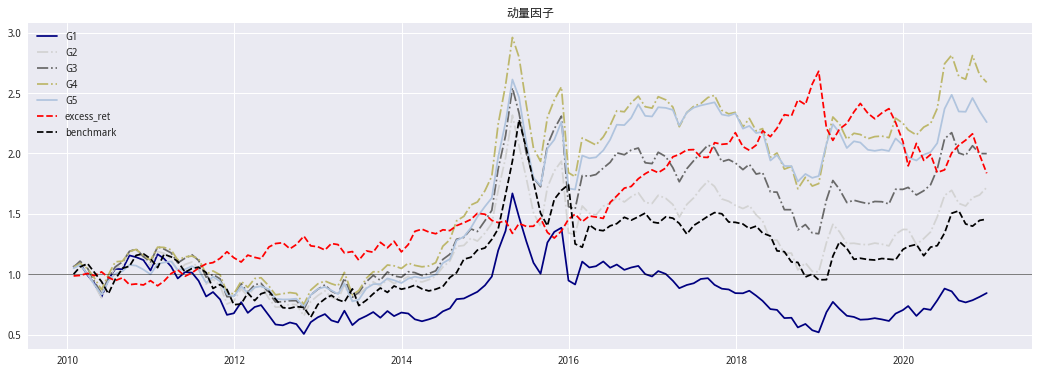

In [22]:
# 对动量因子数据进行分组标记
grouped_dataset = assign_factor_groups(momentum_data_result, 'trend_momentum_indicator')
# 计算各分组的周期收益率序列
group_return_series = compute_group_profit(grouped_dataset)

# 获取并对齐中证500基准收益率
benchmark_price = get_price('000905.XSHG', analysis_start, analysis_end, fields='close')
benchmark_price = benchmark_price.reindex(group_return_series.index)
benchmark_return = benchmark_price['close'].pct_change().fillna(0)
group_return_series['benchmark'] = benchmark_return

# 计算多空组合超额收益
group_return_series['excess_ret'] = group_return_series['G5'] - group_return_series['G1']
# 计算累计净值曲线
cumulative_nav = np.exp(np.log1p(group_return_series).cumsum())

# 绘制动量因子分组净值对比图
draw_net_value_curve(cumulative_nav, '动量因子分组净值走势')

从净值曲线表现可以看出，G4、G5组合收益表现优于沪深300，G1至G3组合则弱于沪深300；表现相对突出的G4与G5组合，净值曲线分布较为集中，相互交叉重叠的现象较为明显；G5组合在回测前期表现偏弱，后期则呈现出优异的收益特征；尽管G5组合的收益水平并非格外突出，但其收益稳定性显著优于其他组别，这一结论也将在后续的策略绩效分析中得到验证。

下图为动量因子月度IC值序列，从结果可以看出，动量因子IC值多数时间位于0轴上方，表明该因子与标的下期收益率呈现正相关关系。

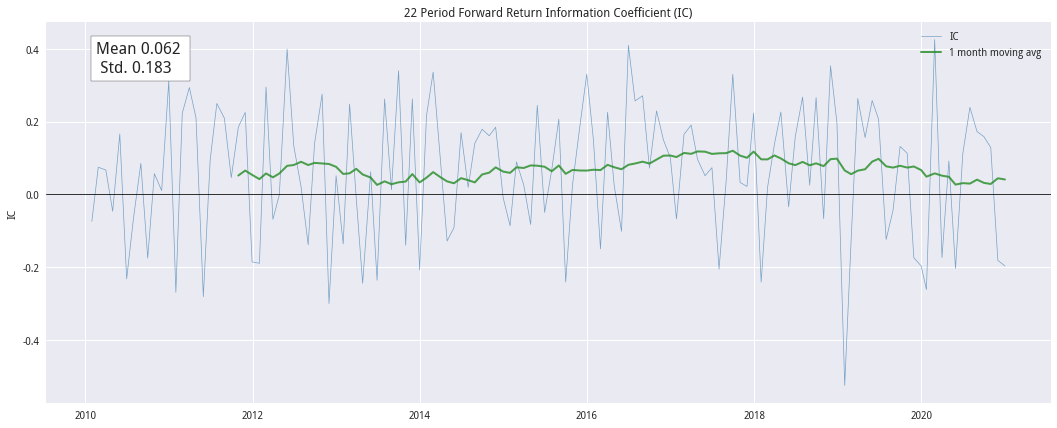

In [9]:
# 转换为Alphalens标准输入格式
formatted_factor = momentum_data_result.rename(
    columns={'trend_momentum_indicator': 'factor', 'next_ret': 22})

# 剔除缺失值，保证因子分析稳定性
formatted_factor = formatted_factor.dropna()

# 计算因子IC值序列
ic_series = performance.factor_information_coefficient(formatted_factor)

# 绘制IC时间序列趋势图
visualization.plot_ic_ts(ic_series);

## 策略表现分析
通过测算各分组与基准组合的年化收益率、收益波动率、夏普比率、最大回撤、Alpha 及信息比率（IR）等核心指标，对各组合收益风险特征进行对比分析。
各组合收益表现与前述净值曲线走势基本一致。从收益水平与风险控制两个维度综合评估，G5 组合整体表现最优。该组合在实现较高超额收益的同时，风险暴露水平更低，收益走势更为稳健；其夏普比率在各组中表现最佳，体现出在单位风险下能够获取更高的风险调整后收益。

In [10]:
# 计算动量因子绩效指标并格式化展示
(evaluate_strategy_metrics(group_return_series).style.format('{:.2%}')
.set_caption('动量因子绩效指标')
.highlight_max(axis=1, color='#d65f5f')
.highlight_min(axis=1, color='#5fba7d'))

,G1,G2,G3,G4,G5,benchmark,excess_ret
年化收益率,-1.54%,5.04%,6.49%,9.03%,7.69%,3.47%,5.67%
波动率,32.06%,29.18%,27.48%,26.41%,23.82%,26.32%,15.53%
夏普,10.93%,31.47%,36.78%,46.02%,43.05%,26.17%,43.46%
最大回撤,-68.94%,-56.01%,-47.49%,-42.34%,-34.88%,-58.18%,-31.52%
IR,-2.43%,1.77%,2.60%,4.42%,2.98%,nan%,-0.14%
Alpha,2.97%,8.45%,9.24%,11.13%,9.26%,nan%,6.29%


# 升级版动量策略
## 出处
Quantitative Momentum: A Practitioner's Guide to Building a Momentum-Based Stock Selection System, WESLEY R. GRAY, Ph.D. JACK R. VOGEL, Ph.D.
## 高质量动量技巧
1、筛选由**价格稳步上行**形成的高动量标的；
2、规避由**大幅波动**驱动形成的高动量标的。

## 技巧说明
由价格平稳缓慢上涨形成的高动量，在样本外区间更易延续上涨趋势，而依靠剧烈波动形成的高动量在样本外表现通常较弱。上述两类特征分别对应行为金融学中的两类认知偏差：

**`偏差一：Limited Attention`**
+ 个体认知资源具有有限性，在特定时点下，大脑更倾向于处理突出且重要的信息，而忽略影响程度较弱的非显著因素。
+ Da et al. (2014) 提出相关假说：多次小幅变化对投资者的吸引力显著低于少数大幅变化，因此投资者对连续信息驱动的股价变动存在反应不足。
+ 该研究提出信息离散性指标（information discreteness，ID），并认为低ID值对应信息连续性更强，属于高质量动量；高ID值对应信息离散性更强，属于低质量动量，ID计算公式如下：
+ `ID=sign(区间收益率)×(区间下跌交易日占比-区间上涨交易日占比)`
+ Da et al.(2014)通过实证检验证实ID为有效的选股因子，且因子取值越小表现越优，同时该因子能够产生Fama-French三因子模型无法解释的超额收益。
+ 与传统动量因子相比，经ID筛选后的高质量动量可实现更高超额收益，且收益在样本外的持续性更强。超额收益的高持续性有利于降低调仓频率、减少换手率并节约交易成本。

**`偏差二：高估值极端事件发生的概率`**
+ 部分个股收益率分布呈现右偏特征，该类标的被定义为“lottery-like”股票。
+ 行为金融学前景理论表明，投资者对小概率事件存在认知偏差，往往会高估其发生概率。
+ 对小概率事件的高估促使投资者过度追逐收益正偏的标的，进而推动其形成高动量。
+ Bali et al. (2011) 采用MAX指标对该现象展开研究，MAX定义为过去1个月日收益率的最大值，美股无涨跌停限制，该指标能更直观反映投资者对彩票类股票的追捧程度。
+ 依据MAX指标将标的分为10组，MAX最高组为彩票类股票，MAX最低组为低波动“无聊”股票。实证结果显示，**“无聊”股票收益显著优于彩票类股票**。

## 适合A股的改进指标
1、针对信息离散性，Da et al.(2014)提出的ID指标在A股市场效果有限。结合筛选低关注度标的的目标，采用**60个交易日日换手率标准差**作为ID代理指标，因子取值越小越好；
2、沿用MAX作为彩票类股票代理指标，定义为**过去20个交易日日收益率最大值**，因子取值同样越小越好。

## 策略思想
1、回测区间：2010年1月1日至2020年12月31日；
2、调仓规则：按月调仓，每月末以收盘价完成交易；
3、股票池：中证500成分股，剔除ST股票及停牌等无法正常交易的标的；
4、交易模型：
+ 采用等权重方式构建综合因子，对基础动量因子Momentum、改进ID指标、改进MAX指标的排名进行加权平均，得到**综合因子得分SCORE**；
+ 每月末更新因子指标并重新排序，单只标的目标仓位为1%，采用等权配置；
+ 依据**综合因子排名**将中证500成分股分为5组，综合因子值越大组合表现越优，按升序排列后组别序号越高表现越好，即G5组表现优于G1组。ORE`；


+ 每月末更新动量指标并重新对股票排名，新股理想仓位为1%，等权配置；


+ 将中证500成分股按`综合因子排名`分为5组，综合因子值越大越好，按由小到大排名，组别越大的组合越好，即G5组优于G1组；

## 策略实现
### 构建改进指标ID、MAX
针对MAX指标（**过去20个交易日的日收益率最大值**）与ID指标（**60个交易日内日换手率的标准差**），需分别提取各调仓日下每只股票对应区间的指标数据，并完成相应计算：其中ID指标需提取各股票过去60个交易日的日换手率数据，进而计算标准差。

In [11]:
class EnhancedMomentumIndicator(Factor):
    """
    进阶优化版动量因子
    融合收益率、波动率、换手率、近期收益极值的综合动量指标
    """
    
    import warnings
    warnings.filterwarnings("ignore")
    
    indicator_name = 'enhanced_momentum_indicator'
    maximum_lookback_period = 62
    required_data_fields = ['close', 'turnover_ratio']
    
    def compute_indicator(self, dataset) -> pd.Series:
        """
        优化动量因子计算逻辑：传统动量 + 换手率稳定性 + 近期收益最大值 + 排名融合
        """
        closing_price = dataset['close']
        
        # 计算日收益率，剔除缺失值与观察日当日数据
        daily_return = closing_price.pct_change().iloc[1:-1]
        turnover_rate = dataset['turnover_ratio'].iloc[1:-1]

        # 计算换手率波动与近期最大收益
        turnover_volatility = turnover_rate.std()
        recent_max_return = daily_return.iloc[-20:].max()

        # 基础指标计算
        return_std = daily_return.std()
        cumulative_return = closing_price.iloc[-1] / closing_price.iloc[0] - 1
        base_momentum = cumulative_return - 3000 * (return_std ** 2)

        # 多因子降序/升序排名融合
        rank_part1 = pd.concat((recent_max_return, turnover_volatility), axis=1).rank(ascending=False)
        rank_part2 = base_momentum.rank(ascending=True)
        
        # 合并排名序列
        combined_ranks = pd.concat((rank_part1, rank_part2), axis=1)
        
        # 等权合成最终优化动量得分
        return combined_ranks.mean(axis=1)

In [12]:
# 配置回测时间区间参数
analysis_start = '2010-01-01'
analysis_end = '2020-12-31'
final_trade_date = '2021-01-27'

# 生成优化动量因子数据集（中证500股票池）
enhanced_momentum_data = generate_factor_dataset('000905.XSHG', analysis_start, analysis_end, final_trade_date, EnhancedMomentumIndicator)

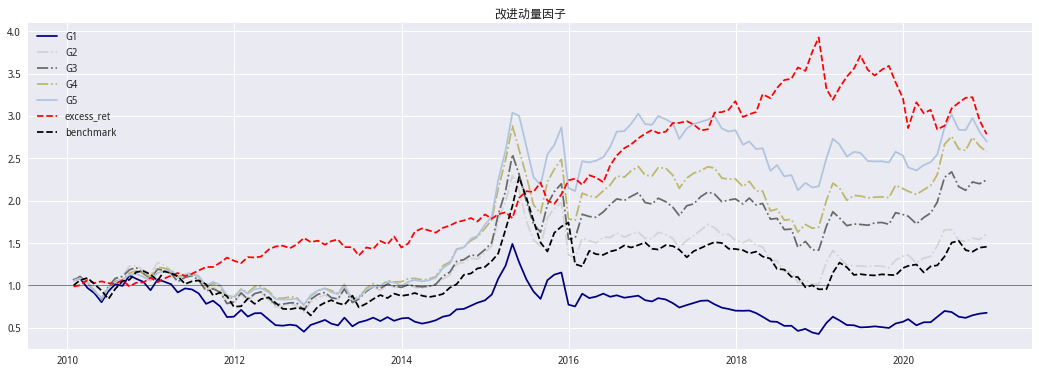

In [23]:
# 优化动量因子分组与收益计算
grouped_dataset2 = assign_factor_groups(enhanced_momentum_data, 'enhanced_momentum_indicator')
group_return_series2 = compute_group_profit(grouped_dataset2)

# 获取并对齐基准收益率
benchmark_price2 = get_price('000905.XSHG', analysis_start, analysis_end, fields='close')
benchmark_price2 = benchmark_price2.reindex(group_return_series2.index)
benchmark_return2 = benchmark_price2['close'].pct_change().fillna(0)
group_return_series2['benchmark'] = benchmark_return2

# 计算多空超额收益与累计净值
group_return_series2['excess_ret'] = group_return_series2['G5'] - group_return_series2['G1']
cumulative_nav2 = np.exp(np.log1p(group_return_series2).cumsum())

# 绘制优化后动量因子净值曲线
draw_net_value_curve(cumulative_nav2, '改进动量因子分组净值走势')

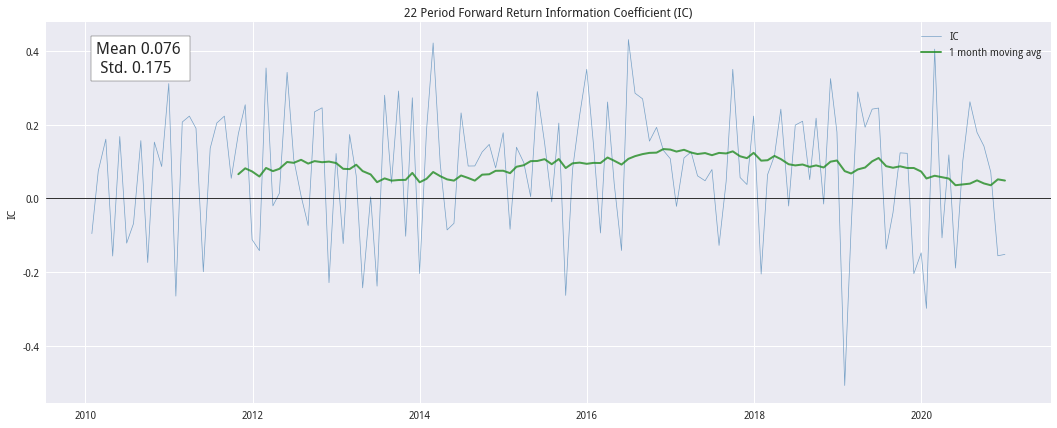

In [14]:
# 转换为 Alphalens 标准分析格式
formatted_factor2 = enhanced_momentum_data.rename(
    columns={'enhanced_momentum_indicator': 'factor', 'next_ret': 22})

# 移除缺失值，保证分析稳定性
formatted_factor2 = formatted_factor2.dropna()

# 计算因子 IC 信息系数
ic_series2 = performance.factor_information_coefficient(formatted_factor2)

# 绘制 IC 时间序列图
visualization.plot_ic_ts(ic_series2);

各组收益表现与前文净值曲线所呈现的结论保持一致。无论从收益水平还是风险控制维度进行分析，G5组合均表现最优，不仅能够实现较高的超额收益，同时风险水平最低、收益走势最为平稳，其夏普比率同样在各组中处于最优水平，在风险承担可控的前提下实现了最高的收益回报。

In [15]:
# 计算并格式化展示改进动量因子的策略绩效指标
(evaluate_strategy_metrics(group_return_series2).style.format('{:.2%}').set_caption('改进动量因子绩效指标')
.highlight_max(axis=1, color='#d65f5f')
.highlight_min(axis=1, color='#5fba7d'))

,G1,G2,G3,G4,G5,benchmark,excess_ret
年化收益率,-3.51%,4.42%,7.63%,8.98%,9.44%,3.47%,9.75%
波动率,31.97%,28.62%,27.72%,26.08%,24.55%,26.32%,15.42%
夏普,4.72%,29.45%,40.44%,46.13%,49.05%,26.17%,68.31%
最大回撤,-71.43%,-56.15%,-44.38%,-43.54%,-34.11%,-58.18%,-29.11%
IR,-3.86%,1.20%,3.46%,4.31%,4.58%,nan%,3.74%
Alpha,1.02%,7.70%,10.42%,11.09%,10.85%,nan%,9.84%


# 结合对国内市场的观察修正动量因子
长期观测数据显示，全市场每日约有2%的股票触及涨停板，其中当日开板与次日开板标的分别占比34.8%、53.8%，能够连续涨停的标的占比较低；每日跌停股票占比为1.6%，其中当日开板比例达45.6%，涨跌停股票的数量占比与持续时间呈现明显的非对称特征。

磁吸效应会使得接近涨停的标的出现非理性上涨、临近跌停的标的出现非理性下跌，而关注度效应则会导致涨跌停标的均被高估定价。因此，涨停股票在后续阶段大概率出现**负向**异常收益，跌停股票的后期表现则取决于磁吸效应与关注度效应的相对强弱。

基于上述市场特征，本文提出区别于前述改进思路的动量因子修正方法：**在计算动量因子时，剔除个股触及涨停交易日的收益率，以此弱化反转效应的显著程度**。

In [38]:
class FilteredMomentumIndicator(Factor):
    """
    涨停过滤型动量因子
    在优化动量基础上，剔除曾经触及涨停的标的，避免涨停溢价干扰
    """
    
    import warnings
    warnings.filterwarnings("ignore")
    
    indicator_name = 'filtered_momentum_indicator'
    maximum_lookback_period = 62
    required_data_fields = ['close', 'turnover_ratio']
    
    def compute_indicator(self, dataset) -> pd.Series:
        """
        因子核心计算逻辑：
        1. 计算基础价格与换手率指标
        2. 过滤触及涨停的股票交易日
        3. 融合累计收益、波动率、换手率、近期收益最大值
        4. 排名合成最终综合因子
        """
        closing_price = dataset['close']
        stock_list = closing_price.columns.tolist()
        period_start = closing_price.index.min()
        period_end = closing_price.index.max()
     
        # 计算日收益率，剔除缺失值与观察日当日数据
        daily_return_series = closing_price.pct_change().iloc[1:-1]
        turnover_series = dataset['turnover_ratio'].iloc[1:-1]

        # 计算换手率标准差与近20日最大日收益
        turnover_deviation = turnover_series.std()
        recent_max_profit = daily_return_series.iloc[-20:].max()
        
        # 对数收益率计算 + 涨停过滤条件
        log_return = np.log(closing_price / closing_price.shift(1))
        no_limit_flag = ~self.check_limit_up(stock_list, period_start, period_end)
        return_deviation = daily_return_series.std()
        
        # 过滤涨停后的累计收益
        filtered_cum_return = (log_return * no_limit_flag).iloc[1:-1].sum()
        core_momentum = filtered_cum_return - 3000 * (return_deviation ** 2)

        # 多维度指标排名融合
        rank_section_1 = pd.concat((recent_max_profit, turnover_deviation), axis=1).rank(ascending=False)
        rank_section_2 = core_momentum.rank(ascending=True)

        # 合并排名并等权合成因子
        combined_rank = pd.concat((rank_section_1, rank_section_2), axis=1)
        final_factor_score = combined_rank.mean(axis=1)
        
        return final_factor_score
    
    @staticmethod
    def check_limit_up(stock_list: list, start_date: str, end_date: str) -> pd.DataFrame:
        """
        静态工具方法：判断股票是否在区间内触及涨停价
        返回布尔值DataFrame，True表示触及涨停
        """
        price_data = get_price(stock_list, start_date=start_date, end_date=end_date, fields=['high', 'high_limit'], panel=False)
        pivoted_data = price_data.pivot(index='time', columns='code')

        return pivoted_data['high'] >= pivoted_data['high_limit']

In [39]:
# 配置因子回测的时间区间参数
test_start = '2010-01-01'
test_end = '2020-12-31'
final_evaluation_date = '2021-01-27'

# 构建涨停过滤版动量因子数据集（中证500股票池）
filtered_momentum_dataset = generate_factor_dataset('000905.XSHG', test_start, test_end, final_evaluation_date, FilteredMomentumIndicator)

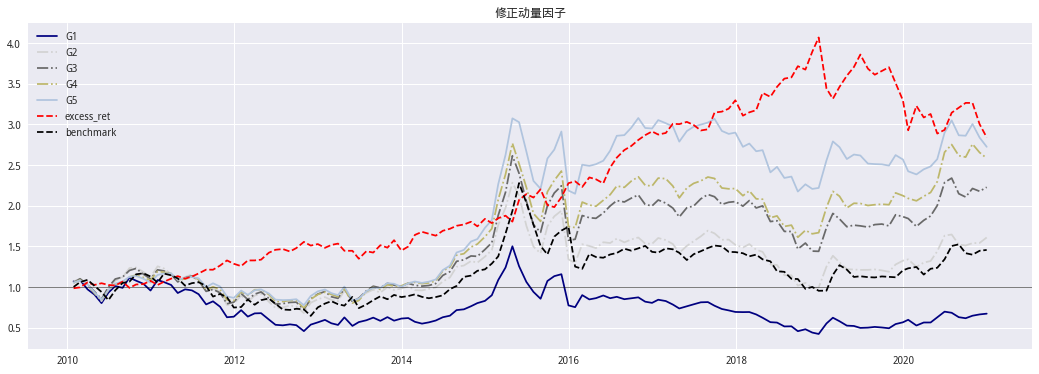

In [40]:
# 对涨停过滤动量因子进行分组标记
grouped_dataset3 = assign_factor_groups(filtered_momentum_dataset, 'filtered_momentum_indicator')
# 计算各分组收益率
group_return_series3 = compute_group_profit(grouped_dataset3)

# 获取并对齐中证500基准收益序列
benchmark_price3 = get_price('000905.XSHG', test_start, test_end, fields='close')
benchmark_price3 = benchmark_price3.reindex(group_return_series3.index)
bench_return3 = benchmark_price3['close'].pct_change().fillna(0)
group_return_series3['benchmark'] = bench_return3

# 计算多空组合超额收益
group_return_series3['excess_ret'] = group_return_series3['G5'] - group_return_series3['G1']
# 计算累计净值曲线
cumulative_nav3 = np.exp(np.log1p(group_return_series3).cumsum())

# 绘制涨停过滤版动量因子净值图
draw_net_value_curve(cumulative_nav3, '修正动量因子分组净值走势')

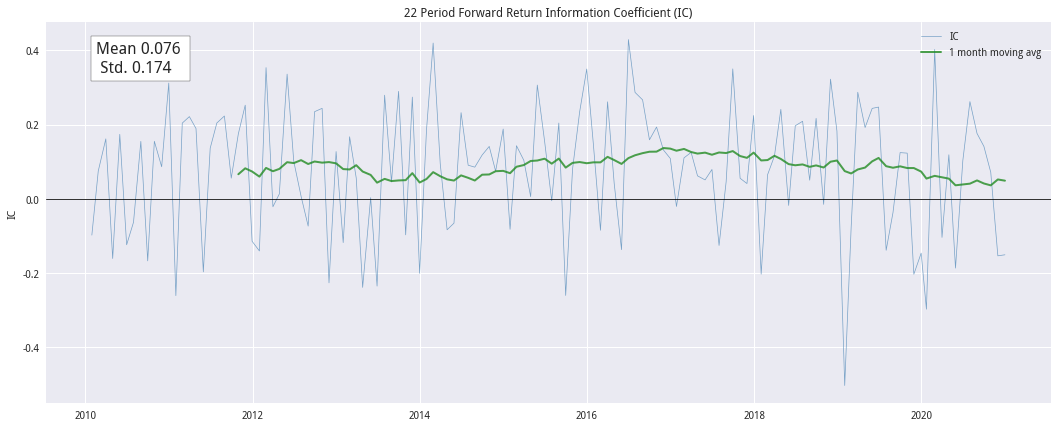

In [41]:
# 转换数据格式以适配 Alphalens 因子分析框架
formatted_factor_3 = filtered_momentum_dataset.rename(
    columns={'filtered_momentum_indicator': 'factor', 'next_ret': 22})

# 清除缺失数据，确保分析过程稳定无异常
formatted_factor_3 = formatted_factor_3.dropna()

# 计算因子信息系数 IC 序列
ic_result_set = performance.factor_information_coefficient(formatted_factor_3)

# 绘制 IC 时间序列变化图表
visualization.plot_ic_ts(ic_result_set);

In [42]:
# 计算涨停过滤动量因子绩效指标并格式化可视化展示
(evaluate_strategy_metrics(group_return_series3).style.format('{:.2%}')
.set_caption('修正动量因子绩效指标')
.highlight_max(axis=1, color='#d65f5f')
.highlight_min(axis=1, color='#5fba7d'))

,G1,G2,G3,G4,G5,benchmark,excess_ret
年化收益率,-3.56%,4.42%,7.55%,9.01%,9.54%,3.47%,9.95%
波动率,31.83%,28.90%,27.64%,26.03%,24.59%,26.32%,15.43%
夏普,4.46%,29.41%,40.21%,46.28%,49.36%,26.17%,69.47%
最大回撤,-71.91%,-56.74%,-44.97%,-41.79%,-33.59%,-58.18%,-30.22%
IR,-3.92%,1.26%,3.39%,4.33%,4.65%,nan%,3.96%
Alpha,0.99%,7.70%,10.30%,11.12%,10.96%,nan%,9.97%


# 基础版策略与升级版策略对比分析
## 策略收益对比分析
将两种策略的回测净值曲线置于同一图表中进行对比可以看出，基础版策略收益表现优于基准指数，升级版策略收益表现则进一步优于基础版策略。

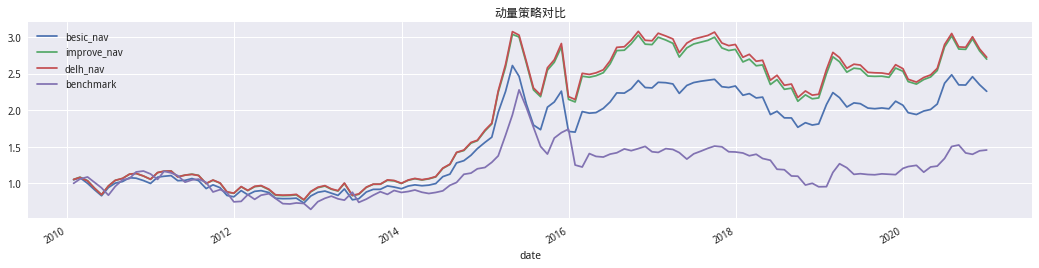

In [43]:
# 整合三类动量因子的最优组净值与基准，进行效果对比
combined_nav_comparison = pd.concat(
    [cumulative_nav['G5'], cumulative_nav2['G5'], cumulative_nav3[['G5', 'benchmark']]], axis=1
)

# 设置清晰的列名，便于区分不同版本动量策略
combined_nav_comparison.columns = ['基础动量净值', '优化动量净值', '修正动量净值', '基准指数']

# 绘制统一的净值对比曲线，直观展示策略优劣
combined_nav_comparison.plot(figsize=(18, 4), title='三类动量因子策略净值对比')

从收益与风险双维度进行评估，升级版策略整体表现最佳，其不仅实现了更高的收益水平，同时将风险控制至最低，收益稳定性表现最为突出，对应的夏普比率也为所有策略中最优，在合理承担风险的前提下达成了最高的收益回报。基础版策略的收益与风险表现同样优于基准指数。

In [27]:
# 合并三种动量因子的收益数据，用于综合绩效对比
combined_return_data = pd.concat(
    [group_return_series['G5'], group_return_series2['G5'], group_return_series3[['G5', 'benchmark']]], axis=1
)
combined_return_data.columns = ['基础动量', '优化动量', '修正动量', '基准指数']

# 计算整体绩效指标
performance_summary = evaluate_strategy_metrics(combined_return_data)

# 格式化输出对比表格，高亮最优/最差指标
(performance_summary.style.format('{:.2%}')
 .set_caption('动量因子综合绩效对比')
 .highlight_max(axis=1, color='#d65f5f')
 .highlight_min(axis=1, color='#5fba7d'))

,besic_nav,improve_nav,delh_nav,benchmark
年化收益率,7.69%,9.44%,9.54%,3.47%
波动率,23.82%,24.55%,24.59%,26.32%
夏普,43.05%,49.05%,49.36%,26.17%
最大回撤,-34.88%,-34.11%,-33.59%,-58.18%
IR,2.98%,4.58%,4.65%,nan%
Alpha,9.26%,10.85%,10.96%,nan%


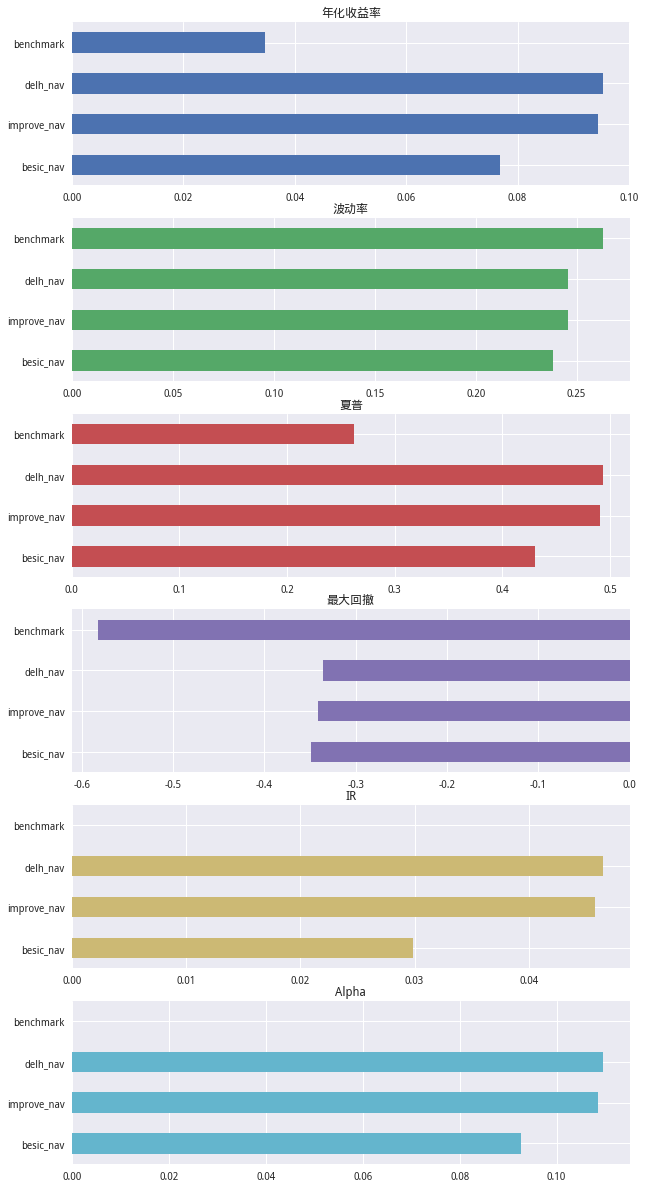

In [28]:
# 横向柱状图展示各因子绩效指标对比，便于直观观察差异
performance_summary.T.plot(kind='barh', subplots=True,
                          figsize=(10, 21), sharex=False, legend=[]);

# 动量策略并不适合所有场景
## 无法继续打败基准
2017年以前，无论市场处于上涨还是下跌阶段，升级版动量策略的表现均持续优于基准；但自2017年起，叠加2018年市场环境变化，升级版动量策略收益表现开始弱于基准，不再具备持续战胜基准的能力。

In [29]:
def calculate_yearly_returns(return_series: pd.DataFrame) -> pd.DataFrame:
    """
    按年度计算策略年化收益率
    按日期分组统计每年收益，索引转换为年份格式便于查看
    """
    yearly_return = return_series.groupby(pd.Grouper(level='date', freq='Y')).apply(
        lambda x: ep.annual_return(x, period='monthly'))
    
    yearly_return.index = yearly_return.index.year
    
    return yearly_return

In [30]:
# 计算修正动量策略与基准的年度收益数据
yearly_return_data = calculate_yearly_returns(combined_return_data[['修正动量', '基准指数']])

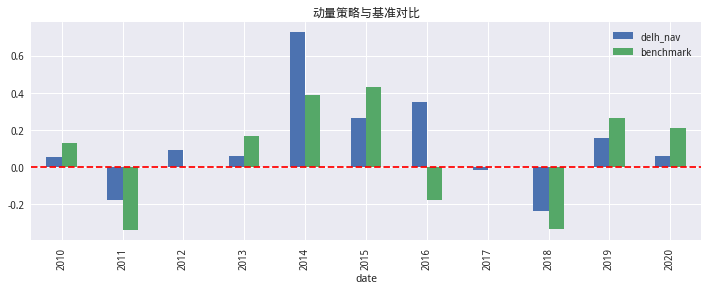

In [31]:
# 绘制年度收益对比柱状图，直观展示每年策略与基准表现
yearly_return_data.plot(kind='bar', figsize=(12, 4), title='修正动量策略与基准指数年度收益对比')
# 添加红色虚线作为零轴参考线
plt.axhline(0, color='red', linestyle='--');

## 动量策略背后的业务支撑
1、普通交易者存在的**认知偏差**，是导致市场定价出现偏差的核心原因；
2、较高的套利成本，使得理性投资者难以充分纠正市场中的定价错误。

## 错误定价成因（Barberis et al. 1998 模型）
1、**当利好盈利消息连续出现时，投资者易产生过度反应**。此时投资者会出现选择性偏差，过度关注近期连续发生的利好信息，并将这种乐观预期延伸至对公司未来股价的判断中；一旦未来公司盈利未达到预期水平，投资者会出现恐慌性抛售行为，进而导致股价下跌，这正是成长投资的核心特征。
2、**当利好盈利消息非连续出现时，投资者则会表现出反应不足**。这种情况下，投资者会产生保守主义偏差，对利好消息持怀疑态度，不愿及时更新对公司基本面的认知，进而无法对股价做出有效调整。随着时间推移，当公司持续释放新的盈利利好时，股价才会逐步向新的基本面水平回归，这也是动量投资的核心逻辑。

## 有限套利
### 较高的套利成本，限制了理性投资者对市场定价错误的纠正能力。

**`有限套利（Limits to Arbitrage）:`**
假设A、B两地均有苹果销售，A地售价为5元/斤，B地售价为10元/斤，可见B地苹果存在明显的定价错误。从理论层面而言，套利者可通过在A地采购苹果、转运至B地销售的方式，赚取每斤5元的差价。随着参与此类套利行为的人数增多，B地苹果供给增加，价格会逐步下降，最终消除定价偏差。

但在实际套利过程中，套利者需综合考虑各类成本，包括A、B两地间的运输成本、苹果的储藏成本、两地商铺租赁费用差异及税收差异等；此外，还需承担苹果价格波动风险——在苹果从A地转运至B地的过程中，其价格可能出现下跌，甚至低于套利者的综合成本。这些因素共同制约了套利者的套利行为，使其无法无顾虑地开展套利操作。

## 聪明投资者的顾虑
1、市场定价错误在短期之内未必会得到修正，反而有可能进一步扩大。
2、对于理性交易者而言，运用动量策略进行交易时，最大的套利风险是**因策略短期表现弱于基准指数而引发的职业风险**。
3、市场中的大部分资金属于短期业绩追逐者（short-sighted performance chasers），这类资金仅依据短期相对于基准的表现来评估基金经理的业绩水平，这让基金经理陷入两难困境。一方面，基金经理希望借助市场定价错误运用动量策略，因为从长期来看，该策略的预期收益能够战胜基准；另一方面，他们开展此类交易的前提是，短期内不会因业绩跑输基准而引发投资者赎回，从而威胁到手中管理的资金规模。

## 对动量策略的正确认识
1、动量策略在短期可能出现跑输市场的情况，因此并非适用于所有投资者（或资金）；
2、从长期视角来看，动量策略能够实现战胜市场的目标。对于那些注重投资过程、以长期盈利为核心目标（不计较短期波动）且能够严格执行交易纪律的投资者而言，动量策略具备配置价值；
3、大量跨市场实证研究表明，**动量与价值是两个长期呈负相关关系的因子**。基于此，**动量策略的最优应用方式是与价值策略相结合**，从而进一步优化投资组合的风险收益特征。